In [27]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# Loading orders dataset 

orders = pd.read_csv("../data/orders.csv")

In [29]:
# Checking first 5 rows

orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [30]:
# Checking dataset shape

print(orders.shape)

(10009, 10)


In [31]:
# Checking column names

print(orders.columns)

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'gross_amount', 'discount_pct', 'delivery_days', 'returned', 'rating'],
      dtype='str')


In [32]:
# Checking missing values

orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

In [33]:
# Converting order_date column into datetime format

orders["order_date"] = pd.to_datetime(orders["order_date"])

In [34]:
# Checking data types

orders.dtypes

order_id                    str
customer_id                 str
order_date       datetime64[us]
category                    str
quantity                  int64
gross_amount            float64
discount_pct            float64
delivery_days             int64
returned                  int64
rating                  float64
dtype: object

In [35]:
# Creating snapshot date

snapshot_date = orders["order_date"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2025-11-30 00:00:00


In [36]:
# Creating RFM table

rfm = orders.groupby("customer_id").agg({
    
    "order_date": lambda x: (snapshot_date - x.max()).days,
    
    "order_id": "count",
    
    "gross_amount": "sum"
})

# Renaming columns

rfm.columns = ["Recency", "Frequency", "Monetary"]

# Checking first 5 rows

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
CUST00001,168,6,2955.57
CUST00002,35,3,1713.10
CUST00003,232,1,649.98
CUST00004,192,1,1604.04
CUST00005,11,6,3910.43


In [37]:
# Checking RFM table shape

print(rfm.shape)

# Summary statistics

rfm.describe()

(2400, 3)


,Recency,Frequency,Monetary
count,2400.000000,2400.000000,2400.000000
mean,106.552083,4.170417,3102.366721
std,103.035447,2.626960,2318.314239
min,1.000000,1.000000,149.000000
25%,23.000000,2.000000,1371.697500
50%,56.000000,4.000000,2621.735000
75%,180.250000,6.000000,4253.452500
max,623.000000,17.000000,27920.050000


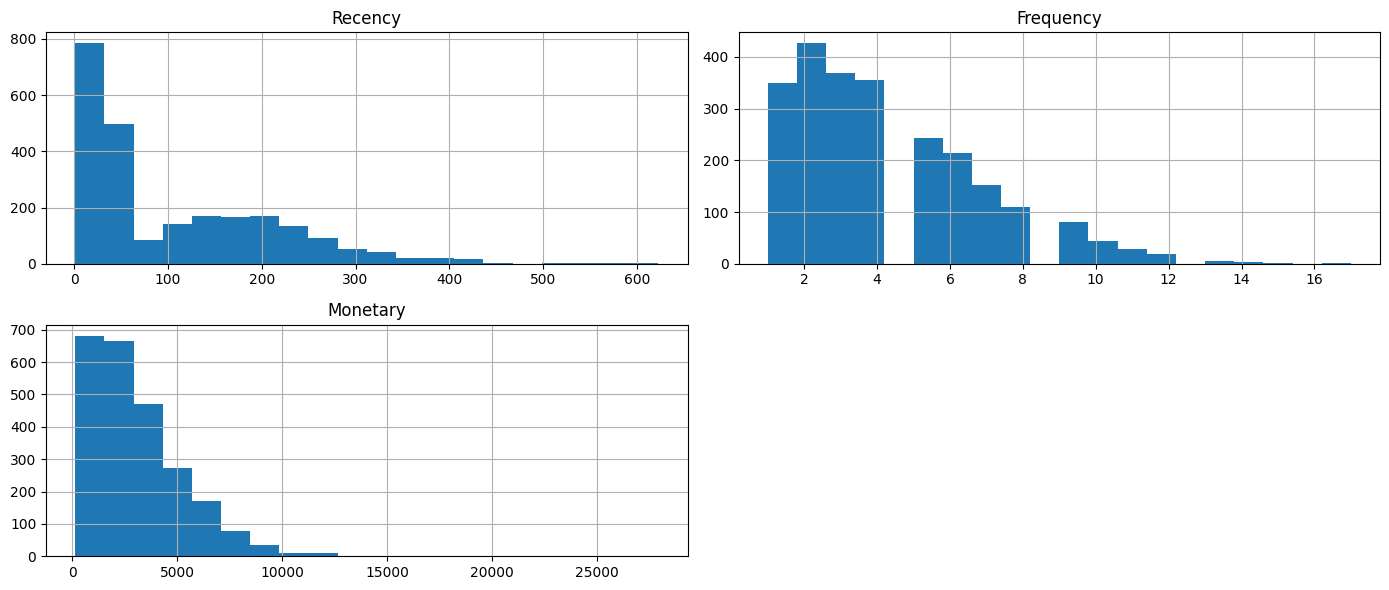

In [38]:
# Plotting RFM distributions

rfm.hist(figsize=(14, 6), bins=20)
plt.tight_layout()
plt.show()

In [39]:
# Observation:
# Most customers have low frequency and monetary values.
# A small number of customers contribute very high spending.
# RFM features are right-skewed.

In [47]:
# Creating RFM scores using quartiles

r_labels = [4,3,2,1]
f_labels = [1,2,3,4]
m_labels = [1,2,3,4]

rfm["R_score"] = pd.qcut(rfm["Recency"], q=4, labels=r_labels)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=4, labels=f_labels)
rfm["M_score"] = pd.qcut(rfm["Monetary"], q=4, labels=m_labels)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
customer_id,,,,,,,,
CUST00001,168,6,2955.57,2,3,3,233,At Risk Customers
CUST00002,35,3,1713.10,3,2,2,322,At Risk Customers
CUST00003,232,1,649.98,1,1,1,111,At Risk Customers
CUST00004,192,1,1604.04,1,1,2,112,At Risk Customers
CUST00005,11,6,3910.43,4,3,3,433,Recent Customers


In [41]:
# Creating combined RFM score

rfm["RFM_Score"] = (
    
    rfm["R_score"].astype(str) +
    
    rfm["F_score"].astype(str) +
    
    rfm["M_score"].astype(str)
)

# Checking first rows

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
customer_id,,,,,,,
CUST00001,168,6,2955.57,2,3,3,233
CUST00002,35,3,1713.10,3,2,2,322
CUST00003,232,1,649.98,1,1,1,111
CUST00004,192,1,1604.04,1,1,2,112
CUST00005,11,6,3910.43,4,3,3,433


In [42]:
# Creating customer segments

def segment_customer(row):
    
    if row["RFM_Score"] == "444":
        return "Best Customers"
    
    elif row["R_score"] == 4:
        return "Recent Customers"
    
    elif row["F_score"] == 4:
        return "Loyal Customers"
    
    elif row["M_score"] == 4:
        return "Big Spenders"
    
    else:
        return "At Risk Customers"

# Applying segmentation

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# Checking first rows

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
customer_id,,,,,,,,
CUST00001,168,6,2955.57,2,3,3,233,At Risk Customers
CUST00002,35,3,1713.10,3,2,2,322,At Risk Customers
CUST00003,232,1,649.98,1,1,1,111,At Risk Customers
CUST00004,192,1,1604.04,1,1,2,112,At Risk Customers
CUST00005,11,6,3910.43,4,3,3,433,Recent Customers


In [43]:
# Checking customer segment distribution

rfm["Segment"].value_counts()

Segment
At Risk Customers    1312
Recent Customers      448
Loyal Customers       400
Best Customers        153
Big Spenders           87
Name: count, dtype: int64

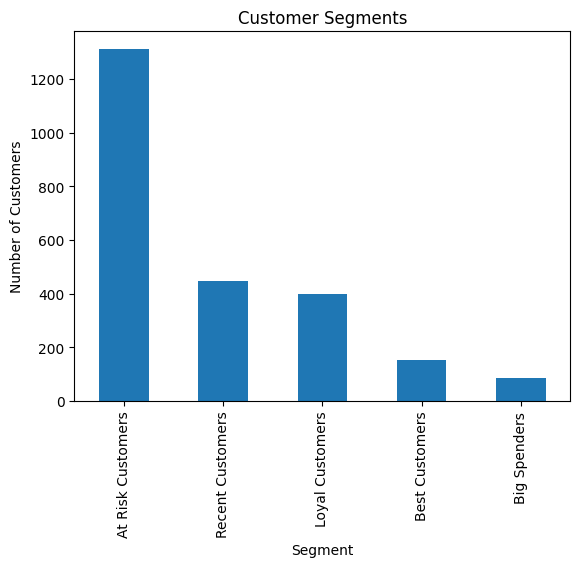

In [44]:
# Visualizing customer segments

rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")

plt.show()

## RFM Business Insights

* Best Customers are highly valuable and should be retained using loyalty rewards and premium offers.

* Recent Customers purchased recently and can be targeted with personalized recommendations.

* Loyal Customers purchase frequently and may respond well to membership programs.

* Big Spenders contribute high revenue and should receive exclusive benefits.

* At Risk Customers may stop purchasing soon and need re-engagement campaigns.